In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

%matplotlib inline


In [ ]:

df = pd.read_csv("data_brute.csv")

print("Aperçu du dataset :")
df.head()


Aperçu du dataset :


,number,post,label
0,0,برافووو حمزة كل الدعم ومزيدا من التألق,happiness
1,0,حسيتك تحكي كيف سيدي علي العروي ،عجبتني اليوم س...,happiness
2,0,افضل صوت مقدم برامج يعجبني حموزة ❤❤❤,happiness
3,0,فهمك للعلوم الانسانية مضحك.على فكرة شعر ابو نو...,disgust
4,0,Sema7ni ama mayssirech ta7ki 3al3bed hakeka l'...,anger


suppression de 1er colonne

In [ ]:
df = df.iloc[:, 1:]


In [ ]:
print("Informations sur le dataset :")
df.info()

Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10594 entries, 0 to 10593
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   post    10594 non-null  object
 1   label   10594 non-null  object
dtypes: object(2)
memory usage: 165.7+ KB


In [ ]:
print("taille :")
print(df.shape)

taille :
(10594, 2)


In [ ]:
print("Statistiques descriptives :")
df.describe()

Statistiques descriptives :


,post,label
count,10594,10594
unique,4217,24
top,...,anger
freq,5624,1311


In [ ]:
print("Valeurs manquantes :")
df.isnull().sum()

Valeurs manquantes :


,0
post,0
label,0


In [ ]:
print(df['label'].unique())

[' happiness' 'happiness' 'disgust' 'anger' 'surprise' 'optimism'
 'sadness' 'fear' 'neutral' 'pessimism' 'label' 'anticipation' 'confusion'
 'pessimism ' ' disgust' ' anticipation' ' optimism' ' neutral' ' sadness'
 ' anger' ' fear' ' pessimism' ' confusion' ' surprise']


nettoyage les espaces inutiles dans les labels:

In [ ]:
df['label'] = df['label'].str.strip()

In [ ]:
df = df[df['label'] != 'label']

df = df.dropna(subset=['label'])



In [ ]:
print(df['label'].unique())

[' happiness' 'happiness' 'disgust' 'anger' 'surprise' 'optimism'
 'sadness' 'fear' 'neutral' 'pessimism' 'anticipation' 'confusion'
 'pessimism ' ' disgust' ' anticipation' ' optimism' ' neutral' ' sadness'
 ' anger' ' fear' ' pessimism' ' confusion' ' surprise']


In [ ]:
df['label'] = df['label'].astype(str).str.strip()


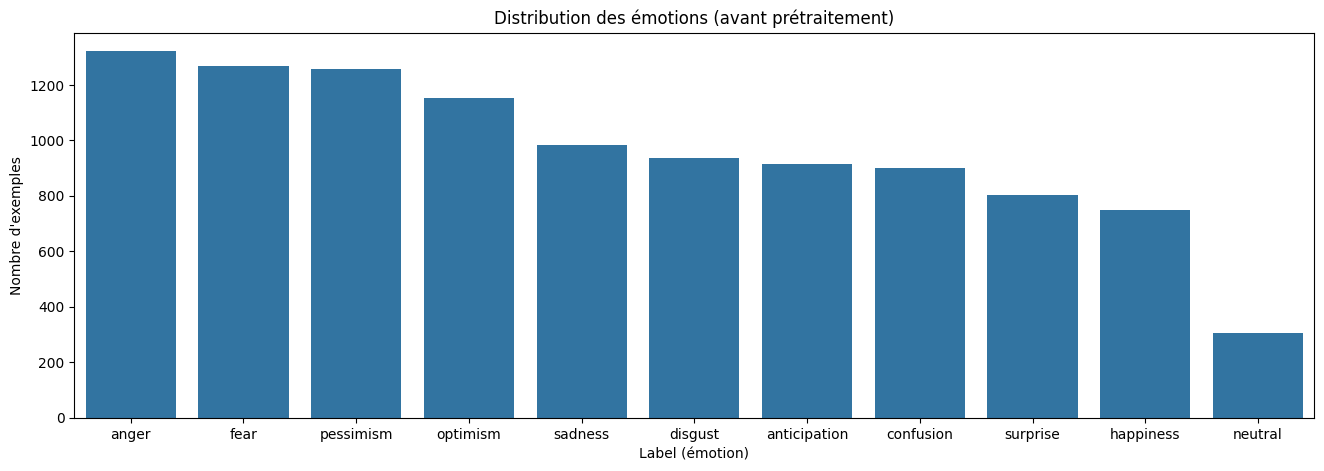


Distribution des labels :
label
anger           1322
fear            1269
pessimism       1259
optimism        1154
sadness          982
disgust          935
anticipation     916
confusion        899
surprise         802
happiness        750
neutral          305
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(16,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Distribution des émotions (avant prétraitement)")
plt.xlabel("Label (émotion)")
plt.ylabel("Nombre d'exemples")
plt.show()

print("\nDistribution des labels :")
print(df['label'].value_counts())

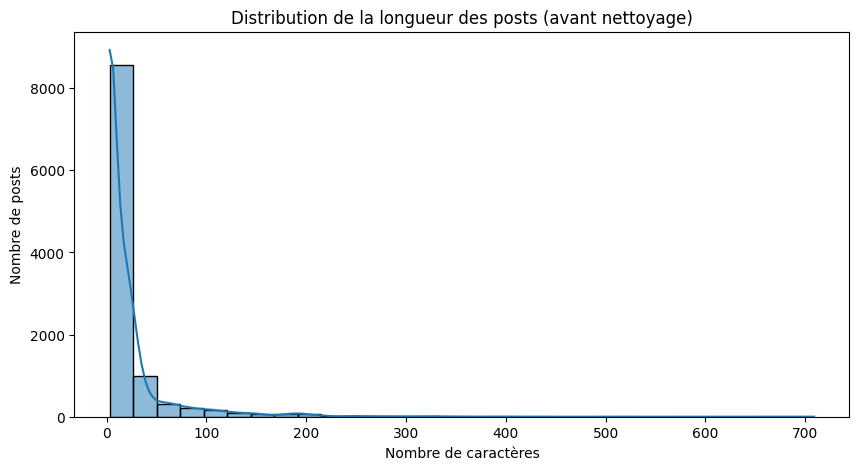

In [ ]:
df['post_length'] = df['post'].astype(str).apply(len)
plt.figure(figsize=(10,5))
sns.histplot(df['post_length'], bins=30, kde=True)
plt.title("Distribution de la longueur des posts (avant nettoyage)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de posts")
plt.show()

In [ ]:
!pip install langdetect


In [ ]:
from langdetect import detect, DetectorFactory
import pandas as pd
import re
DetectorFactory.seed = 0

def detect_lang(text):
  text = str(text).lower()

    # caractères arabes
  if re.search(r'[\u0600-\u06FF]', text):
    return "ar"

    # arabizi (chiffres typiques)
  if re.search(r'[235679]', text):
    return "dialect"

  try:
      lang = detect(text)
      if lang in ["fr", "en"]:
        return lang
      else:
        return "dialect"
  except:
      return "dialect"

df["lang"] = df["post"].apply(detect_lang)
df["lang"].value_counts()


,count
lang,
dialect,5676
ar,4916
fr,1


In [ ]:
df = df.drop(df[df['lang'] == 'fr'].index)


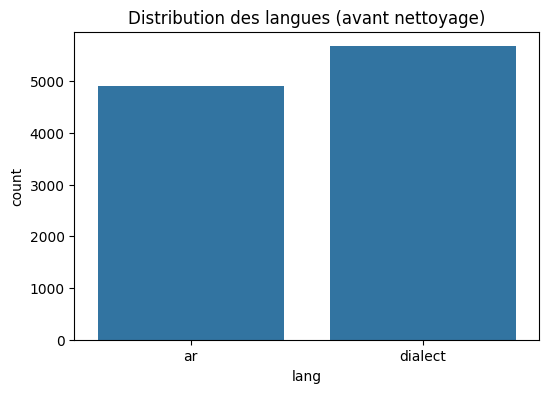


Nombre d'exemples par langue :
lang
dialect    5676
ar         4916
Name: count, dtype: int64


In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='lang')
plt.title("Distribution des langues (avant nettoyage)")
plt.show()

print("\nNombre d'exemples par langue :")
print(df['lang'].value_counts())

In [ ]:
print("\nStatistiques descriptives sur la longueur des posts :")
print(df['post_length'].describe())


Statistiques descriptives sur la longueur des posts :
count    10592.000000
mean        21.268316
std         41.046022
min          3.000000
25%          3.000000
50%          3.000000
75%         22.000000
max        709.000000
Name: post_length, dtype: float64


Nombre de lignes contenant "..." ou du texte vide

In [ ]:
missing_text = df[df['post'].astype(str).str.strip() == "..."]
print(f"Lignes avec texte manquant : {len(missing_text)}")

Lignes avec texte manquant : 5624


Supprimer ces lignes:

In [ ]:
df = df[df['post'].astype(str).str.strip() != "..."]
df = df[df['post'].notna()]

print("Nouvelle taille du dataset :", df.shape)

Nouvelle taille du dataset : (4968, 4)


Vérifier les doublons et les supprimer:

In [ ]:

print("Nombre de doublons :", df.duplicated().sum())

df = df.drop_duplicates()
print("Taille après suppression des doublons :", df.shape)


Nombre de doublons : 740
Taille après suppression des doublons : (4228, 4)


In [ ]:
print(df.columns)

Index(['post', 'label', 'post_length', 'lang'], dtype='object')


In [ ]:
print("Aperçu du dataset après nettoyage :")
df.head()

Aperçu du dataset après nettoyage :


,post,label,post_length,lang
0,برافووو حمزة كل الدعم ومزيدا من التألق,happiness,39,ar
1,حسيتك تحكي كيف سيدي علي العروي ،عجبتني اليوم س...,happiness,57,ar
2,افضل صوت مقدم برامج يعجبني حموزة ❤❤❤,happiness,36,ar
3,فهمك للعلوم الانسانية مضحك.على فكرة شعر ابو نو...,disgust,81,ar
4,Sema7ni ama mayssirech ta7ki 3al3bed hakeka l'...,anger,189,dialect


In [ ]:
df.to_csv("clean_data.csv", index=False)
print("Dataset nettoyé sauvegardé sous 'clean_data.csv'")


Dataset nettoyé sauvegardé sous 'clean_data.csv'


In [ ]:
from google.colab import files
files.download("clean_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Distribution des labels (après nettoyage)


Distribution des labels :
label
pessimism       519
optimism        459
anticipation    450
disgust         445
sadness         410
anger           407
fear            380
surprise        322
confusion       289
happiness       284
neutral         263
Name: count, dtype: int64


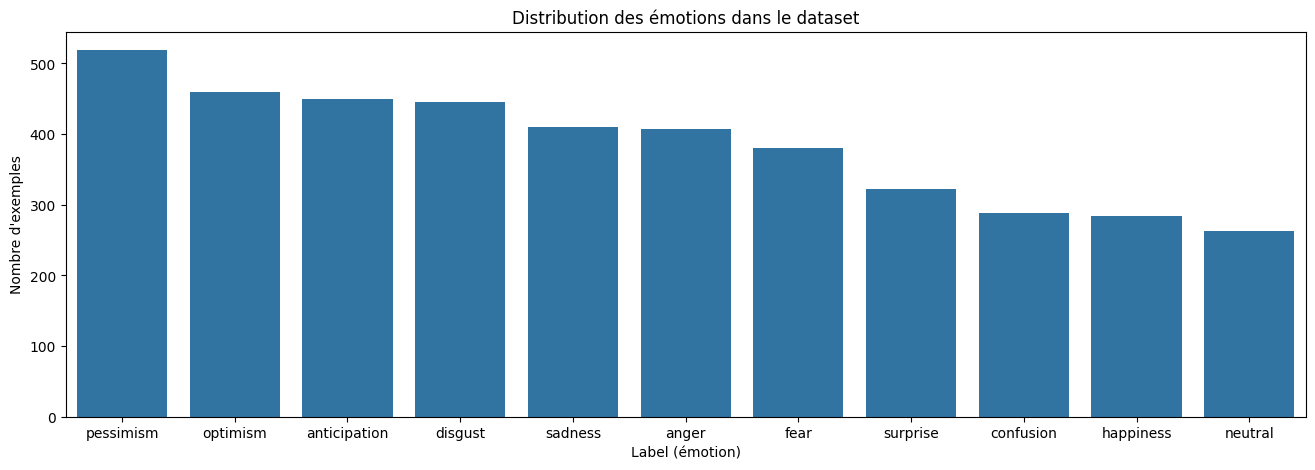

In [ ]:

print("\nDistribution des labels :")
print(df['label'].value_counts())


plt.figure(figsize=(16,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Distribution des émotions dans le dataset")
plt.xlabel("Label (émotion)")
plt.ylabel("Nombre d'exemples")
plt.show()


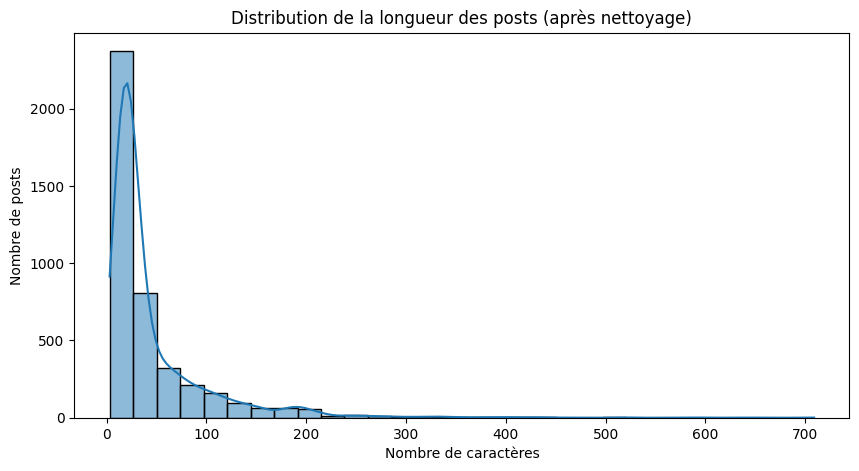

In [ ]:
df['clean_post_length'] = df['post'].astype(str).apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df['clean_post_length'], bins=30, kde=True)
plt.title("Distribution de la longueur des posts (après nettoyage)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de posts")
plt.show()


Boxplot du nombre de mots par label
Pourquoi c’est utile :

Certains labels (comme anger ou disgust) peuvent avoir des posts plus longs ou plus courts que happiness.

Cela aide à détecter des anomalies ou posts très longs/courts.

Utile pour choisir des limites de séquence si tu passes à un modèle NLP (ex. LSTM, BERT).

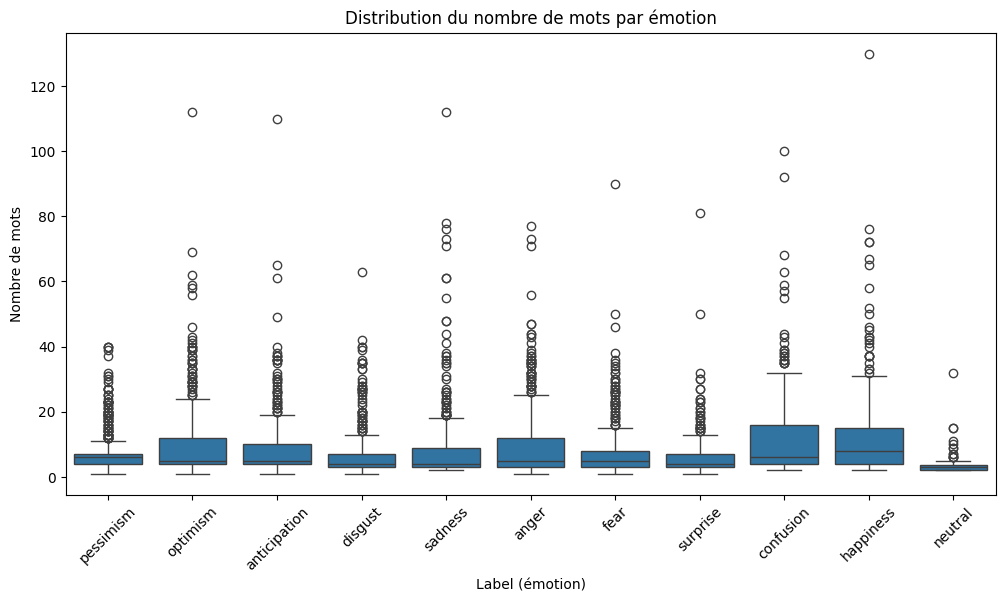

In [ ]:
# Créer une colonne avec le nombre de mots
df['word_count'] = df['post'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='label', y='word_count', order=df['label'].value_counts().index)
plt.title("Distribution du nombre de mots par émotion")
plt.xlabel("Label (émotion)")
plt.ylabel("Nombre de mots")
plt.xticks(rotation=45)
plt.show()


In [ ]:
print(df['word_count'])

0         7
1        10
2         7
3        15
4        28
         ..
10588     3
10589     3
10590     3
10591     4
10592     3
Name: word_count, Length: 4228, dtype: int64


In [ ]:
print(df['post_length'])

0         39
1         57
2         36
3         81
4        189
        ... 
10588     17
10589     16
10590     19
10591     17
10592     15
Name: post_length, Length: 4228, dtype: int64


**Features engineering**

1.Data Transformation:(translate dialect and clean text)


*stopwords* arabe:

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

arabic_stop = set(stopwords.words('arabic'))
print(arabic_stop)

{'سادس', 'ساء', 'صهٍ', 'أغسطس', 'فلان', 'بهن', 'أمامك', 'أخو', 'قام', 'تحوّل', 'ليسوا', 'زاي', 'هاهنا', 'إيانا', 'ريث', 'نوفمبر', 'لكنما', 'طالما', 'فوق', 'قرش', 'كي', 'تسع', 'أضحى', 'سبحان', 'باء', 'جميع', 'إيه', 'أحد', 'لها', 'ج', 'ء', 'أوشك', 'كِخ', 'الألاء', 'آي', 'اللاتي', 'نيسان', 'لست', 'ستمئة', 'ذي', 'كلَّا', 'كن', 'ثلاثمائة', 'سبعمائة', 'خبَّر', 'أمّا', 'عشرون', 'هَيْهات', 'أفعل به', 'تفعلين', 'عشر', 'أنا', 'يوليو', 'مع', 'تِه', 'حقا', 'عل', 'ثمَّ', 'هذا', 'به', 'لكم', 'هذان', 'مافتئ', 'ثمانمئة', 'حتى', 'خاصة', 'ذاك', 'لما', 'ستة', 'اللذان', 'لم', 'أنتم', 'بك', 'إن', 'فاء', 'حبيب', 'اللتين', 'هيت', 'لكن', 'بَسْ', 'تلكم', 'هن', 'عليك', 'صبرا', 'أربعاء', 'ّأيّان', 'إليكن', 'فرادى', 'إذاً', 'لعل', 'مساء', 'لكيلا', 'غداة', 'يا', 'هلّا', 'اربعون', 'إنَّ', 'أكثر', 'أى', 'ش', 'و', 'جعل', 'ما انفك', 'وَيْ', 'كأيّن', 'ضاد', 'والذين', 'أبريل', 'بس', 'واو', 'يفعلون', 'فيم', 'تموز', 'ليرة', 'أرى', 'جوان', 'سرا', 'إنا', 'ذواتي', 'مادام', 'آمينَ', 'الآن', 'بسّ', 'تلكما', 'تسعة', 'أمد', 'كرب

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
dialect_extra = {"ما", "ش", "باش", "بش", "كيما", "برشا", "عال", "علاش", "شنو", "وين", "عند", "هاو", "هاك", "مش", "كان"}
arabic_stop = arabic_stop.union(dialect_extra)


nettoyage texte arabe:

In [ ]:
import re
import pandas as pd
def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)           # supprimer les liens
    text = re.sub(r"@\S+", "", text)              # supprimer les mentions
    text = re.sub(r"#", "", text)                 # supprimer #
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text) # garder seulement les caractères arabes
    text = re.sub(r"\s+", " ", text).strip()      # espaces multiples
    text= " ".join([w for w in text.split() if w not in arabic_stop])
    return text



nettoyage texte français:

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
french_stopwords = set(stopwords.words('french'))

def clean_french_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join([w for w in text.split() if w not in french_stopwords])
    return text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import re

def clean_dialect_text(text):
    text = str(text).lower()

    # supprimer liens
    text = re.sub(r"http\S+|www\S+", "", text)

    # supprimer mentions et hashtags
    text = re.sub(r"@\w+|#", "", text)

    # supprimer emojis
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        "",
        text
    )

    # garder lettres latines + chiffres + espaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # supprimer espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [ ]:
def clean_by_lang(row):
    if row["lang"] == "ar":
        return clean_arabic_text(row["post"])
    elif row["lang"] == "dialect":
        return clean_dialect_text(row["post"])
    else:
        return clean_french_text(row["post"])


df["clean_post"] = df.apply(clean_by_lang, axis=1)


In [ ]:
print("Aperçu du dataset après nettoyage :")
df.head()

Aperçu du dataset après nettoyage :


,post,label,post_length,lang,clean_post_length,word_count,clean_post
0,برافووو حمزة كل الدعم ومزيدا من التألق,happiness,39,ar,39,7,برافووو حمزة الدعم ومزيدا التألق
1,حسيتك تحكي كيف سيدي علي العروي ،عجبتني اليوم س...,happiness,57,ar,57,10,حسيتك تحكي سيدي علي العروي ،عجبتني اليوم سردك ...
2,افضل صوت مقدم برامج يعجبني حموزة ❤❤❤,happiness,36,ar,36,7,افضل صوت مقدم برامج يعجبني حموزة
3,فهمك للعلوم الانسانية مضحك.على فكرة شعر ابو نو...,disgust,81,ar,81,15,فهمك للعلوم الانسانية مضحك فكرة شعر ابو نواس ر...
4,Sema7ni ama mayssirech ta7ki 3al3bed hakeka l'...,anger,189,dialect,189,28,sema7ni ama mayssirech ta7ki 3al3bed hakeka l ...


Translate dialect:

In [ ]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=f3160ca5dbd59854b1b2c6173a22dc4f60d3b478f61818046ccb744dd8713082
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [ ]:
import re
import langid
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch


In [ ]:
model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [ ]:
tun_norm = {
    "ena": "أنا",
    "ana": "أنا",
    "enti": "إنتي",
    "inta": "إنت",
    "houwa": "هو",
    "hiya": "هي",
    "nheb": "نحب",
    "n7eb": "نحب",
    "nhebbo": "نحب",
    "3andi": "عندي",
    "andek": "عندك",
    "andou": "عنده",
    "barcha": "برشا",
    "barsha": "برشا",
    "ktir": "برشا",
    "cherbt": "شربت",
    "mouch": "موش",
    "moch": "موش",
    "mesh": "موش",
    "behi": "باهي",
    "mezyen": "مزيان",
    "mezyena": "مزيانة",
    "sbe7": "الصباح",
    "sbah": "الصباح",
    "leile": "الليل",
    "leila": "الليلة",
    "9olt" : "قلتُ",
"9ali" : "قال لي",
"9otelha" : "قلتُ اها",
"9otlou" : "قلت له",
"9ali" : "قال لي",
"9atli" : "قالت لي",
"3ala5yrr" : "تصبح على خير",
"3adi" : "عادي",
"3ady" : "عادي",
"3ou9ad" : "عُقدْ",
"3ami" : "عمّي",
"3amti" : "عمّتي",
    "sema7ni":"سمحني",
    "Sema7ni":"سمحني",
"5alitha" : "تركتها",
"5aliih" : "تركته",
"5atih" : "ليس له ذنب",
"5ateha" : "ليس لها ذنب",
"5raj" : "خرج",
"5arjet" : "خرجت",
"5arja" : "اخرج",
"De5la" : "ادخل",
"Da5let" : "دخلت",
"D5al" : "دخل",
"De5" : "اغمي عليه",
"De5et" : "اغمي عليها",
"Lyouma" : "اليوم",
"7abit" : "حبيت",
"Y7eb" : "يحب",
"9am" : "قام",
"9omt" : "قمت",
"Y9oum" : "يقوم",
"T9oum" : "تقوم",
"Ra9det" : "رقدت",
"R9ad" : "رقد",
"Yor9od" : "يرقد",
"Or9od" : "أُرقد",
"9bal" : "قبل",
"Ba3ed" : "بعد",
"Sme7" : "السماح",
"Sama7ni" : "سمحني",
"7a9" : "حق",
"7ou9ou9" : "حقوق",
"7asad" : "حسد",
"7osed" : "حُسد",
"Bo8edh" : "بُغض",
"Mit8achech" : "متغشش",
"8och" : "غُش",
"8ayeb" : "غايب",
"7adher" : "حاضر",
"8odhben" : "غُضبان",
"Bithabet" : "بالضبط",
"2ekid" : "أكيد",
"Akid" : "أكيد",
"2badan" : "أبدا",
"7asit" : "حسّيت",
"i7ses" : "إحساس",
"7ases" : "حاسس",
"7asa" : "حاسه",
"M3aya" : "معي",
"M3ah" : "معاه",
"Wa9et" : "وقت",
"9la9" : "قلق",
"Dho7ek" : "ضحك",
"Ydha7ek" : "يضحك",
    "nheb": "نحب",
    "barcha": "برشا",
    "ana": "أنا",
    "enti": "إنتي",
    "inta": "إنت",
    "houwa": "هو",
    "hiya": "هي",
    "ahna": "نحن",
    "homa": "هم",

    "n7eb": "نحب",
    "nhebb": "نحب",
    "3andi": "عندي",
    "andek": "عندك",
    "andou": "عنده",
    "mchit": "ذهبت",
    "tmachit": "تمشيت",
    "khalit": "تركت",
    "5alitha": "تركتها",
    "5aliih": "تركته",
    "barcha": "برشا",
    "barsha": "برشا",
    "behi": "باهي",
    "mouch": "موش",
    "mesh": "موش",
    "mezyen": "مزيان",
    "mezyena": "مزيانة",

    "sbe7": "الصباح",
    "sbah": "الصباح",
    "leila": "الليلة",
    "leile": "الليل",
    "lyouma": "اليوم",
    "9bal": "قبل",
    "ba3ed": "بعد",
    "3ala5yrr": "تصبح على خير",
    "3adi": "عادي",
    "3ady": "عادي",
    "smeh": "السماح",
    "sama7ni": "سمحني",
    "7abit": "حبيت",
    "y7eb": "يحب",
    "9olt": "قلت",
    "9ali": "قال لي",
    "9otlou": "قلت له",
    "9atli": "قالت لي",
    "7a9": "حق",
    "7ou9ou9": "حقوق",
    "7asad": "حسد",
    "7osed": "حُسد",
    "bo8edh": "بُغض",
    "mit8achech": "متغشش",
    "8och": "غُش",
    "8ayeb": "غايب",
    "7adher": "حاضر",
    "8odhben": "غُضبان",
    "bithabet": "بالضبط",
    "2ekid": "أكيد",
    "akid": "أكيد",
    "2badan": "أبدا",
    "7asit": "حسّيت",
    "i7ses": "إحساس",
    "7ases": "حاسس",
    "7asa": "حاسه",
    "m3aya": "معي",
    "m3ah": "معاه",
    "wa9et": "وقت",
    "9la9": "قلق",
    "dho7ek": "ضحك",
    "ydha7ek": "يضحك",

    "3": "ع",
    "7": "ح",
    "9": "ق",
    "5": "خ",
    "2": "ء",
    "8": "غ",
}



In [ ]:
def translate_nllb(text, src_lang="fra_Latn", tgt_lang="arb_Arab"):
    tokenizer.src_lang = src_lang
    encoded = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    generated = model.generate(
        **encoded,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang)
    )

    return tokenizer.decode(generated[0], skip_special_tokens=True)


In [ ]:
def normalize_and_translate_dialect(text):
    words = text.split()
    normalized_words = []

    for w in words:
        w_clean = re.sub(r"[^a-zA-Z0-9]", "", w.lower())

        if w_clean in tun_norm:
            # mot dialect connu
            normalized_words.append(tun_norm[w_clean])
        else:
            # garder le mot tel quel
            normalized_words.append(w)

    normalized_text = " ".join(normalized_words)

    # si encore du latin → traduire
    if re.search(r"[a-zA-Z]", normalized_text):
        translated = translate_nllb(
            normalized_text,
            src_lang="fra_Latn",
            tgt_lang="arb_Arab"
        )
        return translated

    return normalized_text


In [ ]:
tests = [
    "Sema7ni ena nheb barcha",
    "ana farhan barcha el youm",
    "انا فرحان برشا اليوم"
]

for t in tests:
    print("Original :", t)
    print("Résultat :", normalize_and_translate_dialect(t))
    print("------")


Original : fadit bech nor9od
Résultat : فاديت بيك نورود
------
Original : Sema7ni ena nheb barcha
Résultat : سمحني أنا نحب برشا
------
Original : ana farhan barcha el youm
Résultat : أنا فارحان برشا اليوم
------
Original : انا فرحان برشا اليوم
Résultat : انا فرحان برشا اليوم
------


In [ ]:
# Appliquer le pipeline sur toute la colonne clean_post
df['processed_post'] = df['clean_post'].apply(
    lambda x: pd.Series(normalize_and_translate_dialect(x))
)




In [ ]:
# Vérifier le résultat
print(df[['clean_post', 'processed_post', 'lang']][10:20])

                                           clean_post  \
10  برافو لكل ساهم مسلسل صاحبك راجل بداية ونهاية ا...   
11  قلو احلف قالو والله قالو منصدقكش قالو احلف بول...   
12                   maktlaaaaa dhohekk mooooooooooot   
13  sami lfehri ken ma famech 9elet 7ye w wled 7ra...   
14  كريم الغربي حاول تكون متواضع انا نقلك تعلم بسا...   
15  شوف عادا هكا الشخصية تعملو للخرى المغارف تفوه ...   
16  ملا شخصية جايبها تقول عالمة متاع فيزياء الا اب...   
17  الحمدلله ربي يحسن خاتمتنا كملت الفيديو بسيف ال...   
18  وقت نقولو الّي المهندسين التوانسة أغلبهم بهايم...   
19                         nhebek ya hamza mahle zink   

                                       processed_post     lang  
10  برافو لكل ساهم مسلسل صاحبك راجل بداية ونهاية ا...       ar  
11  قلو احلف قالو والله قالو منصدقكش قالو احلف بول...       ar  
12                      ماكلاaaaa dhohekk mooooooooot  dialect  
13  سامي إلفري يَعْرفُ مَعْرِفَتَيْنِ سَبْعَةَ سَن...  dialect  
14  كريم الغربي حاول تكون متواضع انا نقلك تعلم 

In [ ]:

new_df = df[["label", "clean_post","lang"]]

# Sauvegarder dans Google Colab (même répertoire du notebook)
new_df.to_csv("Transformed_dataset.csv", index=False)
print("Fichier sauvegardé dans Colab : Transformed_dataset.csv")





Fichier sauvegardé dans Colab : cleaned_labels_posts.csv


Data Representation:

In [ ]:
!pip install transformers torch tqdm


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from tqdm import tqdm

# Charger le modèle multilingue
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Utiliser GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

In [ ]:
def get_embedding(text):
    # Tokenisation et préparation
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    # Passage dans le modèle
    with torch.no_grad():
        outputs = model(**inputs)

    # Moyenne sur les tokens (768 dimensions)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding


In [ ]:
df_new=pd.read_csv("Transformed_dataset.csv")

In [ ]:
print("\nValeurs uniques des labels :")
print(df_new['label'].unique())

print("\nNombre de lignes :")
print(df_new.shape[0])




Valeurs uniques des labels :
['happiness' 'disgust' 'anger' 'surprise' 'optimism' 'sadness' 'fear'
 'neutral' 'pessimism' 'anticipation' 'confusion']

Nombre de lignes :
4228


In [ ]:
import numpy as np
from tqdm import tqdm

embeddings = []

print("Génération des embeddings XLM-R pour la nouvelle data...")

for text in tqdm(df_new["clean_post"], desc="Encodage XLM-R"):
    emb = get_embedding(str(text))
    embeddings.append(emb)

# Conversion en matrice numpy
X_new = np.array(embeddings)
print("Shape finale des embeddings :", X_new.shape)



Génération des embeddings XLM-R pour la nouvelle data...


Encodage XLM-R: 100%|██████████| 4228/4228 [09:51<00:00,  7.15it/s]

Shape finale des embeddings : (4228, 768)


In [ ]:
df_ar = df_new[df_new["lang"] == "ar"].reset_index(drop=True)

# Embeddings correspondants
X_ar = X_new[df_new["lang"] == "ar"]


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_ar = le.fit_transform(df_ar['label'])
print("Classes :", le.classes_)

Classes : ['anger' 'anticipation' 'confusion' 'disgust' 'fear' 'happiness' 'neutral'
 'optimism' 'pessimism' 'sadness' 'surprise']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ar, y_ar, test_size=0.2, random_state=42, stratify=y_ar,shuffle=True
)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_model = LogisticRegression(
    C=0.1,
    max_iter=4000,
    class_weight="balanced",
    solver="lbfgs",
    multi_class="multinomial"
)

logreg_model.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=0.1, class_weight='balanced', max_iter=4000,
                   multi_class='multinomial')

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

y_pred = logreg_model.predict(X_test_scaled)

present_classes = np.unique(y_test)
target_names_present = le.inverse_transform(present_classes)

print("Accuracy :", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=present_classes,
    target_names=target_names_present,
    zero_division=0
))


Accuracy : 0.5598086124401914
              precision    recall  f1-score   support

       anger       0.47      0.46      0.47        80
anticipation       0.62      0.57      0.59        90
   confusion       0.44      0.55      0.49        58
     disgust       0.67      0.72      0.70        86
        fear       0.60      0.66      0.62        76
   happiness       0.48      0.55      0.51        55
     neutral       0.65      0.65      0.65        52
    optimism       0.66      0.64      0.65        89
   pessimism       0.55      0.50      0.53       104
     sadness       0.47      0.49      0.48        82
    surprise       0.48      0.36      0.41        64

    accuracy                           0.56       836
   macro avg       0.56      0.56      0.56       836
weighted avg       0.56      0.56      0.56       836



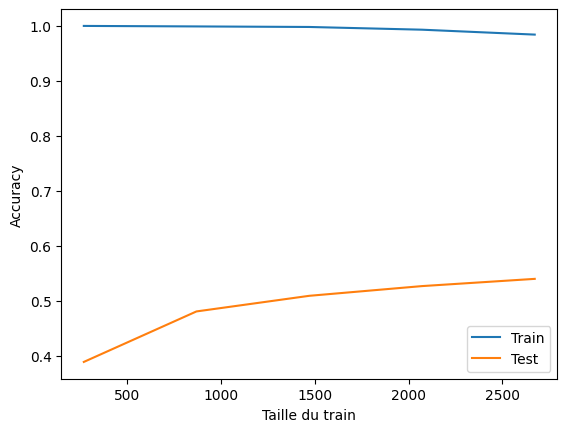

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    logreg_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label='Train')
plt.plot(train_sizes, test_scores_mean, label='Test')
plt.xlabel("Taille du train")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


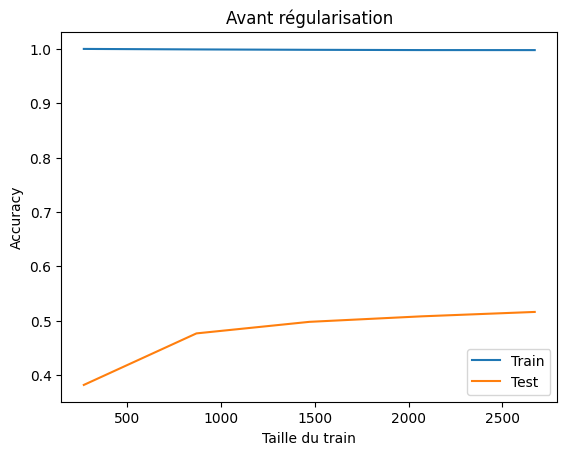

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Scaling des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle sans régularisation forte
logreg_model = LogisticRegression(
    max_iter=4000,
    class_weight="balanced",
    solver="lbfgs",
    multi_class="multinomial"
)

logreg_model.fit(X_train_scaled, y_train)

# Courbe d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    logreg_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test')
plt.xlabel("Taille du train")
plt.ylabel("Accuracy")
plt.title("Avant régularisation")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


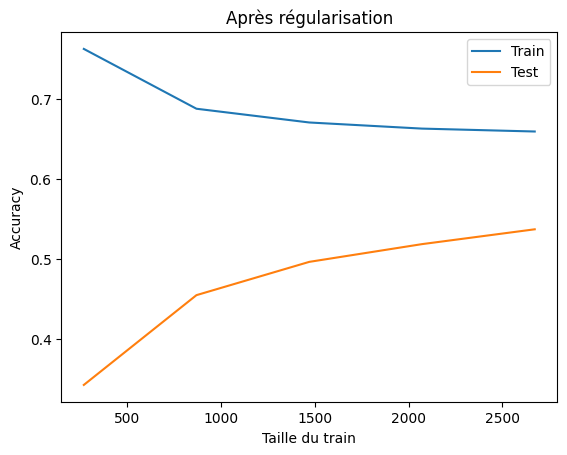

In [ ]:
# Modèle avec régularisation plus forte
logreg_model_reg = LogisticRegression(
    C=0.001,                 # régularisation plus forte
    max_iter=4000,
    class_weight="balanced",
    solver="lbfgs",
    multi_class="multinomial"
)

logreg_model_reg.fit(X_train_scaled, y_train)

# Courbe d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    logreg_model_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test')
plt.xlabel("Taille du train")
plt.ylabel("Accuracy")
plt.title("Après régularisation")
plt.legend()
plt.show()


In [ ]:
test_texts = [
    "انا فرحان برشا اليوم",          # happiness
    "قلبي موجوع برشا",               # sadness
    "قرفت من الوضع",                 # pessimism
    "نهار عادي "     # neutral
]

# Générer les embeddings
emb_test = np.array([get_embedding(t) for t in test_texts])

# Normaliser
emb_test_scaled = scaler.transform(emb_test)

# Prédiction
pred = logreg_model_reg.predict(emb_test_scaled)
pred_labels = le.inverse_transform(pred)

# Affichage
for t, p in zip(test_texts, pred_labels):
    print(f"Texte : {t}")
    print(f"Prédiction : {p}")
    print("-" * 30)


Texte : انا فرحان برشا اليوم
Prédiction : happiness
------------------------------
Texte : قلبي موجوع برشا
Prédiction : sadness
------------------------------
Texte : قرفت من الوضع
Prédiction : pessimism
------------------------------
Texte : نهار عادي 
Prédiction : neutral
------------------------------
